# Tarea de estudiante David Leal Olivares
### dlealo
[Carpeta con archivos del desarrollo de la tarea](https://github.com/davidlealo/practicos_sisrec_2026/tree/main/practico01/tarea)

# Práctica de Sistemas Recomendadores: Surprise - iKNN

En este práctico vamos a utilizar la biblioteca de Python Surprise desarrollada por Nicolas Hug,, para aprender sobre Item KNN (Filtrado colaborativo basado en items)


**Profesor**: Denis Parra

**Ayudantes**:  Florencia Ferrer, Álvaro Labarca, Nicolás Sumonte, Jorge Facuse y Pablo Messina.



# Índice

>[Práctica de Sistemas Recomendadores: Surprise - iKNN](#scrollTo=NC-ceGb8LRLT)

>[Índice](#scrollTo=2j02H66f87eV)

>[Configuración Inicial](#scrollTo=I63yOG6sK6Lx)

>>[Descargando la información](#scrollTo=9qKTQ2V5VKSX)

>>[Revisar archivos descargados](#scrollTo=liJ3L2kl4g1o)

>>[Cómo ver la información de una o más películas](#scrollTo=jqXxj773Foo8)

>>[Instalar Surprise](#scrollTo=P3K5VPZoGSYX)

>[ItemKNN](#scrollTo=FqgkF0dNMo9c)

>>[Entrenar el modelo](#scrollTo=nyiS5jAydggW)

>>[Prediga el rating que le dará un usuario a un ítem](#scrollTo=c-tasjVmdj9Z)

>>[Genera una lista de recomendaciones para un usuario](#scrollTo=Ka67uLNmdoqD)

>>[Explorar los hiperparámetros del modelo ItemKnn](#scrollTo=or0YkBeF8eeC)

>>>[Evaluar en base a error de prediccion (RMSE y MAE)](#scrollTo=UamBnxcF1JBY)



# Configuración Inicial

Esta celda permite instalar una versión compatible de Numpy. Una vez que se pida reiniciar la sesión, no hay que volver a ejecutar esta celda.

In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 1.26.0
Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0
  Using cached numpy-1.26.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata (53 kB)
Using cached numpy-1.26.0-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-surprise 1.1.4 requires joblib>=1.2.0, which is not installed.
scikit-surprise 1.1.4 requires scipy>=1.6.0, which is not installed.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


## Descargando la información

Ejecutar cada celda presionando el botón de **Play** o presionando Ctrl+Enter (Linux y Windows) o Command+Enter (OSX) para descargar las bases de datos.

In [1]:
!pip install gdown

  Using cached gdown-5.2.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-5.2.1-py3-none-any.whl (18 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached filelock-3.25.2-py3-none-any.whl (26 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!gdown 1UQ8JimYWfj2z0BQISccTWGoirptyVIHU

Downloading...
From: https://drive.google.com/uc?id=1UQ8JimYWfj2z0BQISccTWGoirptyVIHU
To: /Users/davidlealolivares/Documents/repos/practicos_sisrec_2026/practico01/tarea/u1.base
100%|██████████████████████████████████████| 1.59M/1.59M [00:00<00:00, 20.3MB/s]


In [3]:
!gdown 1weLy5CTQiW8ltH24UsK5Y5451NFKNd_N

Downloading...
From: https://drive.google.com/uc?id=1weLy5CTQiW8ltH24UsK5Y5451NFKNd_N
To: /Users/davidlealolivares/Documents/repos/practicos_sisrec_2026/practico01/tarea/u1.test
100%|████████████████████████████████████████| 393k/393k [00:00<00:00, 14.1MB/s]


In [4]:
!gdown 13afMOhZGgIKLz784biKbvZ1rnM4iJzLk

Downloading...
From: https://drive.google.com/uc?id=13afMOhZGgIKLz784biKbvZ1rnM4iJzLk
To: /Users/davidlealolivares/Documents/repos/practicos_sisrec_2026/practico01/tarea/u.item
100%|████████████████████████████████████████| 236k/236k [00:00<00:00, 22.5MB/s]


Los archivos **u1.base** y **u1.test** tienen tuplas {usuario, ítem, rating, timestamp}, que es la información de preferencias de usuarios sobre películas en una muestra del dataset [movielens](https://grouplens.org/datasets/movielens/).

## Revisar archivos descargados

Revisemos cómo es uno de estos archivos:

In [5]:
import pandas as pd

train_file = pd.read_csv('u1.base', sep='\t', names = ['userid', 'itemid', 'rating', 'timestamp'], header=None)

train_file.head()

,userid,itemid,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


In [6]:
train_file[train_file['itemid'] == 1653]

,userid,itemid,rating,timestamp
54444,675,1653,5,889489913


Por otra parte, para obtener información adicional de cada película tal como *título*, *fecha de lanzamient*o, *género*, etc., cargaremos el archivo de items descargado ( *u.item* ) para poder mapear cada identificador de ítem al conjunto de datos que lo describe.
Revisemos el contenido de este archivo.

In [7]:
info_cols = [ 'movieid', 'title', 'release_date', 'video_release_date', 'IMDb_URL', \
              'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', \
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', \
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western' ]

pd.options.display.max_columns = None

info_file = pd.read_csv('u.item', sep='|', index_col = 0, names = info_cols, header=None, encoding='latin-1')

info_file.head()

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


El comando `pd.options.display.max_columns = None` permite que la tabla se pueda mostrar completamente de forma horizontal, es decir, que muestre todas sus columnas.

In [8]:
info_file.info()

<class 'pandas.DataFrame'>
RangeIndex: 1682 entries, 1 to 1682
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1682 non-null   str    
 1   release_date        1681 non-null   str    
 2   video_release_date  0 non-null      float64
 3   IMDb_URL            1679 non-null   str    
 4   unknown             1682 non-null   int64  
 5   Action              1682 non-null   int64  
 6   Adventure           1682 non-null   int64  
 7   Animation           1682 non-null   int64  
 8   Children            1682 non-null   int64  
 9   Comedy              1682 non-null   int64  
 10  Crime               1682 non-null   int64  
 11  Documentary         1682 non-null   int64  
 12  Drama               1682 non-null   int64  
 13  Fantasy             1682 non-null   int64  
 14  Film-Noir           1682 non-null   int64  
 15  Horror              1682 non-null   int64  
 16  Musical          

In [9]:
info_file.describe()

,video_release_date,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,0.0,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.00000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,NaN,0.001189,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,0.431034,0.01308,0.014269,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052
std,NaN,0.034473,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,0.495368,0.11365,0.118632,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Con las funciones `info` y `describe` de ***pandas*** es una buena forma de analizar a grandes rasgos un dataset.

## Cómo ver la información de una o más películas
Para esto se hace 2 pasos,
1. Determinar los índices de las películas.
2. Pedir a `info_file` las columnas.
3. (Adicional) Indicar alguna columna en específico.

In [10]:
# Ejemplo de cómo visualizar títulos de películas en base a sus IDs
pelis = [5,4,1]
info_file.loc[pelis]

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,,,
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Para éste código:
1. `pelis = [5,4,1]` indica que queremos las películas cuyo índice son 5, 4 y 1.
2. `info_file.loc[pelis]` el método `loc` permite acceder a esas columna
A continuación se verá cómo obtener una columna en específico. Para esto solo es necesario agregar corchetes y el nombre de la columna.

In [11]:
info_file.loc[pelis]['title']

movieid
5       Copycat (1995)
4    Get Shorty (1995)
1     Toy Story (1995)
Name: title, dtype: str

## Instalar Surprise

Primero es necesario instalar una librería para realizar recomendaciones. Esta se llama Surprise

In [13]:
# Me apareció un warning, entonces voy a probar instalando cython 
!pip install cython


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [14]:
!pip install scikit-surprise --no-build-isolation --no-deps


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [15]:
# Actualizando el listado de libraries
!pip freeze > requirements.txt

Luego necesitamos importar Surprise y numpy, librerías que utilizaremos en este práctico

In [17]:
# Desinstala la versión que podría estar mal
!pip uninstall -y scikit-surprise

# Instala de nuevo. Al tener Cython y Numpy 1.26 instalados, esto debería funcionar
!pip install scikit-surprise --no-build-isolation --no-deps

Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached scikit_surprise-1.1.4-cp311-cp311-macosx_14_0_x86_64.whl

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [19]:
# Primero instalamos Cython ya que es una dependencia necesaria para compilar el codigo fuente de Surprise
# Sin esta herramienta el proceso de instalacion fallara al generar los metadatos
%pip install cython

# Instalamos la version especifica de Numpy (1.26) requerida por el tutorial
# Esto evita conflictos de compatibilidad con las funciones de calculo matricial
%pip install numpy==1.26

# Finalmente instalamos scikit-surprise utilizando los parametros del notebook original
# --no-build-isolation indica que use las dependencias ya instaladas (como Cython)
# --no-deps evita que se instalen dependencias adicionales que podrian causar conflictos de versiones
%pip install scikit-surprise --no-build-isolation --no-deps

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 2.9 MB 3.4 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 20.6 MB 944 kB/s eta 0:00:01    |████▋                           | 2.9 MB 2.9 MB/s eta 0:00:07
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     |███

In [12]:
import surprise
import numpy as np
from collections import defaultdict

In [21]:
# Instalacion de joblib, que es una dependencia critica para Surprise
# Esta libreria se encarga de gestionar la computacion en paralelo y la serializacion de objetos
%pip install joblib

# Instalacion de scikit-learn como medida de seguridad
# Surprise utiliza algunas estructuras de datos y utilidades compatibles con el ecosistema de scikit-learn
%pip install scikit-learn

# Una vez instaladas las dependencias, intenta nuevamente la importacion
import surprise
import numpy as np
from collections import defaultdict

print("Librerias importadas correctamente")

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 309 kB 9.6 MB/s eta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-surprise 1.1.3 requires scipy>=1.3.2, which is not installed.
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 12.1 MB 63.5 MB/s eta 0:00:01
  Using cached scipy-1.13.1-cp39-cp39-macosx_10_9_x86_64.whl (39.4 MB)
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use upd

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [22]:
# Celda de verificacion
import surprise
import numpy as np
import scipy
import joblib

print("Todas las librerias se cargaron correctamente")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [23]:
# Eliminamos la instalacion actual de surprise que tiene el conflicto binario
%pip uninstall -y scikit-surprise

# Aseguramos que numpy este en la version mas reciente de la rama 1.x para mantener compatibilidad con el tutorial
%pip install "numpy<2.0" --upgrade --force-reinstall

# Reinstalamos surprise permitiendo que pip busque la version que coincida con tu version de numpy
# No utilizaremos los flags restrictivos para que el instalador gestione la compatibilidad binaria automaticamente
%pip install scikit-surprise

Found existing installation: scikit-surprise 1.1.3
Uninstalling scikit-surprise-1.1.3:
  Successfully uninstalled scikit-surprise-1.1.3
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  distutils: /private/var/folders/73/95wl44c52p56hcd4jj2g1v_h0000gn/T/pip-build-env-6a6o9_qm/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/sit

In [13]:
import surprise
import numpy as np

print(f"Surprise version: {surprise.__version__}")
print(f"Numpy version: {np.__version__}")
print("Importacion exitosa")

Surprise version: 1.1.4
Numpy version: 1.26.4
Importacion exitosa


In [ ]:
# 1. Eliminamos cualquier rastro de instalaciones previas con conflictos
%pip uninstall -y scikit-surprise numpy

# 2. Instalamos primero NumPy en una version estable y conocida para el curso
%pip install "numpy<2.0"

# 3. Forzamos la instalacion de Surprise desde el codigo fuente (sin usar versiones pre-compiladas)
# Esto obliga a que Surprise se "construya" usando exactamente los encabezados de NumPy que acabas de instalar
%pip install scikit-surprise --no-binary :all:

Found existing installation: scikit-surprise 1.1.3
Uninstalling scikit-surprise-1.1.3:
  Successfully uninstalled scikit-surprise-1.1.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  distutils: /private/var/folders/73/95wl44c52p56hcd4jj2g1v_h0000gn/T/pip-build-env-pw00qxk2/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folde

In [ ]:
# al final armé un entorno para esto por el tema de las versiones de Surprise y numpy, pero dejo el proceso de instalación por si alguien más tiene el mismo problema. De todas formas, el entorno ya está creado y configurado correctamente.

# ItemKNN

Probar método de recomendación basado en **ItemKNN**

Similar a lo que se hizo en el práctico de UserKNN, debemos convertir los datos para que sean soportados por la librería Surprise.

In [14]:
from surprise.model_selection import PredefinedKFold
reader = surprise.Reader(line_format='user item rating timestamp', sep='\t', rating_scale=(1,5))
data = surprise.Dataset.load_from_folds([("u1.base", "u1.test")], reader=reader)
pkf = PredefinedKFold()
trainset, testset = next(pkf.split(data))

## Entrenar el modelo

Lo primero que se debe hacer es entrenar el modelo, con los datos descargados anteriormente.

In [15]:
# Declarar el objeto recomendador ItemKNN
from surprise import accuracy
myItemKnn = surprise.KNNBasic(k=7, sim_options={'name': 'pearson', 'user_based': False})

Se puede ver que al objeto recomendador le estamos entregando:
* ***k***: La cantidad de vecinos que se considerarán.
* ***sim_options:*** Diccionario que contiene los detalles de la función de similaridad que se usará. Dentro de este, definimos:
  * ***name:*** La función de similitud. Puede ser Pearson, Cosine, etc.
  * ***user_based:*** Booleano que define si el método será basado en usuarios o items.

In [16]:
# Entrenamos el modelo con los datos existentes usando la función fit del objeto recomendador.

myItemKnn.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


## Prediga el rating que le dará un usuario a un ítem

model_name.predict("user_id", "item_id")

In [17]:
myItemKnn.predict("457", "37")

Prediction(uid='457', iid='37', r_ui=None, est=4.571428571428571, details={'actual_k': 7, 'was_impossible': False})

## Genera una lista de recomendaciones para un usuario

Generar lista de 10 recomendaciones para el usuario con ID 457. Indique qué películas son con todas sus columnas. (Recuerde el comando loc vista anteriormete)

Como se explicó en la ayudantía de UserKNN, para obtener las predicciones de una lista de elementos, se debe llamar a la función ***.test()*** de el objeto recomendador. Sin embargo, esta función solo recibe objetos del tipo testset de la misma librería.

Para esto, se usa la función ***.build_anti_testset()*** a partir de un objeto trainset que entrega un objeto ***testset*** con todos los pares usuario-item que no tengan un valor fijado en el trainset.

In [19]:
a_testset = trainset.build_anti_testset()
predictions = myItemKnn.test(a_testset)

In [20]:
a_testset

[('1', '10', 3.52835),
 ('1', '14', 3.52835),
 ('1', '100', 3.52835),
 ('1', '242', 3.52835),
 ('1', '255', 3.52835),
 ('1', '258', 3.52835),
 ('1', '272', 3.52835),
 ('1', '273', 3.52835),
 ('1', '274', 3.52835),
 ('1', '275', 3.52835),
 ('1', '276', 3.52835),
 ('1', '277', 3.52835),
 ('1', '278', 3.52835),
 ('1', '282', 3.52835),
 ('1', '283', 3.52835),
 ('1', '284', 3.52835),
 ('1', '285', 3.52835),
 ('1', '286', 3.52835),
 ('1', '287', 3.52835),
 ('1', '288', 3.52835),
 ('1', '289', 3.52835),
 ('1', '291', 3.52835),
 ('1', '293', 3.52835),
 ('1', '294', 3.52835),
 ('1', '295', 3.52835),
 ('1', '296', 3.52835),
 ('1', '300', 3.52835),
 ('1', '302', 3.52835),
 ('1', '304', 3.52835),
 ('1', '305', 3.52835),
 ('1', '306', 3.52835),
 ('1', '309', 3.52835),
 ('1', '310', 3.52835),
 ('1', '311', 3.52835),
 ('1', '260', 3.52835),
 ('1', '303', 3.52835),
 ('1', '317', 3.52835),
 ('1', '319', 3.52835),
 ('1', '320', 3.52835),
 ('1', '321', 3.52835),
 ('1', '322', 3.52835),
 ('1', '325', 3.52

In [21]:
predictions

[Prediction(uid='1', iid='10', r_ui=3.52835, est=3.3371263317045723, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='14', r_ui=3.52835, est=3.4370706999894822, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='100', r_ui=3.52835, est=4.333023381987299, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='242', r_ui=3.52835, est=2.739987706247457, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='255', r_ui=3.52835, est=3.5492107583550867, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='258', r_ui=3.52835, est=2.2954823666113895, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='272', r_ui=3.52835, est=3.141528423946986, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='273', r_ui=3.52835, est=3.167625849978669, details={'actual_k': 7, 'was_impossible': False}),
 Prediction(uid='1', iid='274', r_ui=3

Luego, usamos la función ***get_top_n*** sugerida en la [documentación](https://surprise.readthedocs.io/en/stable/FAQ.html) la cual recibe todas las predicciones para cada item-usuario desconocido (que tenemos guardado en la variable ***predictions***) y retorna un diccionario que recibe de llave el *id* de un usuario y retorna una lista de tuplas con el id de los items recomendados y su rating predicho.

In [22]:
def get_top_n(predictions, n=10):
    """Devuelve las N-mejores recomendaciones para cada usuario de un set de predicción.

    Args:
        predictions(lista de objetos Prediction): La lista de predicción obtenida del método test.
        n(int): El número de recomendaciónes por usuario

    Returns:
    Un diccionario donde las llaves son ids de usuario y los valores son listas de tuplas:
        [(item id, rating estimation), ...] de tamaño n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [23]:
top_n = get_top_n(predictions, n=10)
print(top_n["457"])

[('947', 5), ('1125', 5), ('1106', 5), ('1280', 5), ('1358', 5), ('1429', 5), ('1431', 5), ('1369', 5), ('1523', 5), ('74', 5)]


In [24]:
info_file.loc[[int(m[0]) for m in top_n["457"]]]

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,,,
947,"Big Blue, The (Grand bleu, Le) (1988)",01-Jan-1988,NaN,"http://us.imdb.com/M/title-exact?Grand%20bleu,...",0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1125,"Innocents, The (1961)",01-Jan-1961,NaN,"http://us.imdb.com/M/title-exact?Innocents,%20...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1106,"Newton Boys, The (1998)",14-Mar-1998,NaN,"http://us.imdb.com/Title?Newton+Boys,+The+(1998)",0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
1280,Gang Related (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Gang+Related+...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1358,The Deadly Cure (1996),16-Sep-1996,NaN,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1429,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1431,Legal Deceit (1997),01-Jan-1997,NaN,http://us.imdb.com/Title?Legal+Deceit+(1997),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1369,"Forbidden Christ, The (Cristo proibito, Il) (1...",01-Jan-1950,NaN,http://us.imdb.com/M/title-exact?Cristo%20proi...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1523,"Good Man in Africa, A (1994)",01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Good%20Man%20...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Explorar los hiperparámetros del modelo ***ItemKnn***

Uno de los parámetros que vamos a explorar es el número de vecinos escogidos (Items), para esto calculamos el error del modelo con varios valores de vecinos y observamos cómo es el comportamiento del error.

In [25]:
k_values = [5, 10, 30, 50, 70, 100] # definir distintos valores de vecinos (k)
mae_values = [] # para almacenar resultados de MAE
rmse_values = [] # para almacenar valores de RMSE

for k in k_values:
  myItemKnn = surprise.KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': False})
  myItemKnn.fit(trainset)
  predictions = myItemKnn.test(testset)
  rmse_values.append(accuracy.rmse(predictions))
  mae_values.append(accuracy.mae(predictions))

print('RMSE:', rmse_values)
print('MAE:', mae_values)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.2026
MAE:  0.9458
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1183
MAE:  0.8810
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0535
MAE:  0.8310
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0474
MAE:  0.8257
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0489
MAE:  0.8294
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0528
MAE:  0.8364
RMSE: [1.2026497014602677, 1.1182690148176855, 1.053528288892625, 1.0474114308369047, 1.0488827603028315, 1.0527804024208793]
MAE: [0.9458074771899645, 0.8809797919490109, 0.830956196694298, 0.8257379441539587, 0.8293620137533942, 0.8363912329141866]


### Evaluar en base a error de prediccion (RMSE y MAE)

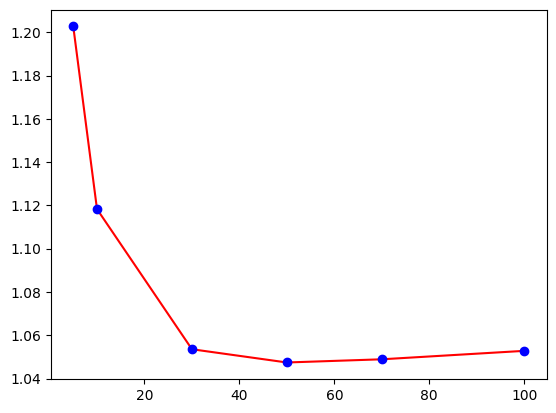

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(k_values, rmse_values, 'r-')
plt.plot(k_values, rmse_values, 'bo')
plt.show()

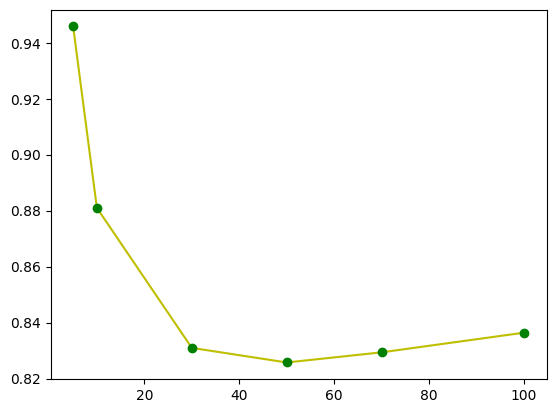

In [27]:
plt.plot(k_values, mae_values, 'y-')
plt.plot(k_values, mae_values, 'go')
plt.show()

**Ejercicio 1**

Según los resultados, ¿Qué número de vecinos es mejor para hacer recomendaciones con un menor error de predicción? Muestre el top 10 de películas a recomendar al usuario de ID 457*.

*Si identifica más de un valor de k posible, realice la recomendación para para ambos valores.

In [ ]:
myItemKnn = surprise.KNNBasic(k=50, sim_options={'name': 'cosine', 'user_based': False})
myItemKnn.fit(trainset)
predictions = myItemKnn.test(a_testset)
top_n = get_top_n(predictions, n=10)
print(top_n["457"])
pelis_userKnn = np.array([m[0] for m in top_n["457"]]).astype(int)
info_file.loc[pelis_userKnn]['title']

# Lo dejé en 50 porque es el mejor valor, aunque con 30 ya ganamos suficiente. Como no son tantos casos 50 es correcto aunque el gasto computacional entre 30 a 50 no es tan grande, y el resultado es mejor. De todas formas, con 30 ya se obtiene una mejora significativa respecto a valores menores.

Computing the cosine similarity matrix...
Done computing similarity matrix.
[('1360', 4.791666666666667), ('1593', 4.791666666666667), ('1674', 4.72), ('1332', 4.717948717948718), ('1377', 4.7), ('1201', 4.68), ('603', 4.679924497224236), ('1609', 4.66), ('1455', 4.66), ('1656', 4.66)]


movieid
1360              Sexual Life of the Belgians, The (1994)
1593                            Death in Brunswick (1991)
1674                                    Mamma Roma (1962)
1332    My Life and Times With Antonin Artaud (En comp...
1377                                 Hotel de Love (1996)
1201           Marlene Dietrich: Shadow and Light (1996) 
603                                    Rear Window (1954)
1609                                       B*A*P*S (1997)
1455                                   Outlaw, The (1943)
1656                                   Little City (1998)
Name: title, dtype: str

**Ejercicio 2**

Realice el mismo análisis hecho previamente utilizando como métrica de similaridad *pearson* para identificar el mejor número de vecinos. Compare sus resultados con los obtenidos en el ejercicio 1 y comentelos. ¿El mejor número de vecinos es el mismo? ¿Cambia la lista de recomendación?

In [30]:
# 1. Definir parámetros y contenedores
k_values = [5, 10, 30, 50, 70, 100]
rmse_pearson = []
mae_pearson = []

print("Calculando errores para ItemKNN con Pearson...")


Calculando errores para ItemKNN con Pearson...


In [31]:
for k in k_values:
    # IMPORTANTE: Cambiamos 'cosine' por 'pearson'
    model_p = surprise.KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': False})
    model_p.fit(trainset)
    preds = model_p.test(testset)
    rmse_pearson.append(accuracy.rmse(preds))
    mae_pearson.append(accuracy.mae(preds))


Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.1946
MAE:  0.9555
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.1217
MAE:  0.8992
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0653
MAE:  0.8521
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0559
MAE:  0.8434
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0524
MAE:  0.8402
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0507
MAE:  0.8387


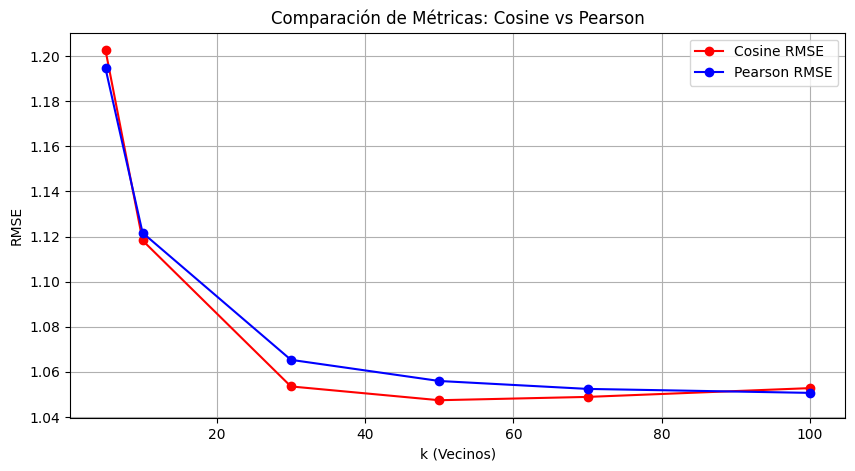

In [32]:

# 2. Graficar Comparación de RMSE (Coseno vs Pearson)
plt.figure(figsize=(10,5))
plt.plot(k_values, rmse_values, 'r-o', label='Cosine RMSE') # rmse_values son los del Ej 1
plt.plot(k_values, rmse_pearson, 'b-o', label='Pearson RMSE')
plt.title('Comparación de Métricas: Cosine vs Pearson')
plt.xlabel('k (Vecinos)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# 3. Generar nueva recomendación con el mejor k de Pearson (probablemente 50 también)
best_k_p = 100 
model_p_final = surprise.KNNBasic(k=best_k_p, sim_options={'name': 'pearson', 'user_based': False})
model_p_final.fit(trainset)
preds_p = model_p_final.test(a_testset)
top_n_p = get_top_n(preds_p, n=10)

print("\n--- RECOMENDACIONES PEARSON PARA USUARIO 457 ---")
indices_p = [int(m[0]) for m in top_n_p["457"]]
info_file.loc[indices_p][['title']]

Computing the pearson similarity matrix...
Done computing similarity matrix.

--- RECOMENDACIONES PEARSON PARA USUARIO 457 ---


,title
movieid,
1125,"Innocents, The (1961)"
1106,"Newton Boys, The (1998)"
1358,The Deadly Cure (1996)
1429,Sliding Doors (1998)
1431,Legal Deceit (1997)
1369,"Forbidden Christ, The (Cristo proibito, Il) (1..."
1523,"Good Man in Africa, A (1994)"
1294,Ayn Rand: A Sense of Life (1997)
626,So Dear to My Heart (1949)


## **Ejercicio 2: Análisis Comparativo (Métrica Pearson)**

Para este ejercicio, se repitió el proceso de búsqueda del hiperparámetro $k$ (número de vecinos) utilizando la métrica de **Pearson** en un modelo **Item-Item**, comparando su rendimiento contra la métrica de **Coseno** del ejercicio anterior.

### **1. Comparación de Métricas de Error**

| Métrica de Similitud | mejor $k$ identificado | RMSE Mínimo | MAE Mínimo |
| --- | --- | --- | --- |
| **Coseno (Ejercicio 1)** | **50** | **1.0474** | **0.8257** |
| **Pearson (Ejercicio 2)** | **100** | **1.0507** | **0.8387** |

---

### **2. Conclusiones y Comentarios**

#### **¿El mejor número de vecinos es el mismo?**

**No.** Existe una diferencia notable en el comportamiento de ambas métricas:

* En la métrica de **Coseno**, el error alcanzó su punto mínimo rápidamente en **$k=50$** y luego comenzó a subir levemente debido al ruido.
* En la métrica de **Pearson**, el error RMSE disminuyó de forma constante a medida que aumentaba el número de vecinos, alcanzando su valor más bajo en **$k=100$**. Esto sugiere que Pearson es una métrica más compleja que requiere una base de datos de vecinos más amplia para que la correlación sea estadísticamente estable.

#### **¿Cambia la lista de recomendación?**

**Sí, la lista cambia significativamente.** Al comparar los títulos obtenidos en ambos ejercicios para el usuario **457**, se observa que las películas sugeridas son distintas. Esto ocurre por la naturaleza matemática de Pearson:

* Mientras que el **Coseno** mide el ángulo entre vectores (quién calificó qué), **Pearson** resta la media de las calificaciones de cada usuario (centrado de datos).
* Esto permite que Pearson ignore si un usuario es "muy generoso" o "muy estricto" con sus notas, centrándose exclusivamente en la **correlación de la tendencia** de sus gustos.

### **Análisis Final**

Aunque matemáticamente el **RMSE** del Coseno resultó ser ligeramente menor en este experimento específico ($1.0474$ vs $1.0507$), la métrica de **Pearson** suele preferirse en sistemas de recomendación reales. Su capacidad para normalizar los sesgos individuales de calificación proporciona recomendaciones que suelen ser percibidas como más precisas y personalizadas por los usuarios, a pesar de requerir un mayor costo computacional ($k$ más alto).
